In [1]:
# Setup
import math_toolkit
math_toolkit.activate()


# Radon data from a continuous image function

This notebook treats each `radon-cat` bitmap as samples of a function on the unit square

$$
[0,1]^2.
$$

The source function is always the continuous piecewise-linear interpolation of the original `1000 x 1000` data. No smaller image replaces the source. Whenever the notebook plots, integrates, or reconstructs, it evaluates this full interpolated function or a Fourier series obtained from it.

At a point $(x,y)$, the interpolated value is the weighted average of the four neighboring samples. Coordinates are wrapped modulo $1$, so the square is used as a chart for the flat torus $\mathbb T^2=\mathbb R^2/\mathbb Z^2$.


## The torus Radon transform

For a primitive integer direction

$$
v=(p,q) \in \mathbb Z^2,
$$

the torus Radon transform averages the interpolated image function along the closed torus line in that direction:

$$
R_v f(x)=\int_0^1 f(x+t v)\,dt.
$$

The result is constant along the line direction $v$. The independent coordinate is the quotient coordinate

$$
\theta = qx_1-px_2 \pmod 1.
$$

So we can write

$$
R_v f(x)=G_v(qx_1-px_2).
$$

If

$$
G_v(\theta)=\sum_{r\in\mathbb Z}\widehat f(r(q,-p))e^{2\pi i r\theta},
$$

then the one-dimensional Fourier coefficients of $G_v$ recover the two-dimensional Fourier coefficients of $f$ along the frequency line perpendicular to $v$:

$$
\widehat f(r(q,-p))=\int_0^1 G_v(\theta)e^{-2\pi i r\theta}\,d\theta.
$$


## From a requested coefficient to a Radon direction

To recover $\widehat f(n,m)$, put

$$
d=\gcd(|n|,|m|),
\qquad
(w_1,w_2)=\frac{1}{d}(n,m).
$$

Choose the line direction perpendicular to $w$:

$$
v=(-w_2,w_1)=(p,q).
$$

Then $(q,-p)=w$, so $(n,m)=d(q,-p)$. The desired coefficient is the $d$-th Fourier coefficient of the projection $G_v$.

To sample $G_v$ at a quotient coordinate $\theta$, choose integers $a,b$ with

$$
q a-p b=1.
$$

Then $x(\theta)=(a\theta,b\theta)$ satisfies $qx_1-px_2=\theta$, and

$$
G_v(\theta)=\int_0^1 f(a\theta+pt,\;b\theta+qt)\,dt.
$$

The code below approximates integrals by uniform quadrature. The function being evaluated is always the full `1000 x 1000` bilinear interpolant.


## Load the images and define the interpolated function

The BMP loader is local to the notebook so it works in JupyterLite without Pillow. The important function here is `evaluate_bilinear_torus`. Given an image array and coordinates, it wraps the coordinates into $[0,1)$ and returns the weighted average of the four neighboring pixel samples.


In [2]:
from math import atan2, gcd
from pathlib import Path

import ipywidgets as widgets
import numpy as np
import plotly.graph_objects as go
from IPython.display import clear_output, display
from plotly.subplots import make_subplots


IMAGE_FILES = ["radon-cat-1.bmp", "radon-cat-2.bmp"]
DEFAULT_K = 9
MIN_K = 2
MAX_K = 200
SINOGRAM_THETA_COUNT = 256
SINOGRAM_LINE_QUADRATURE_COUNT = 256
RADON_DATA_BUDGET_FACTOR = 4
PLOT_GRID_SIZE = 300
SINOGRAM_MAX_NORMAL = 8


def load_bmp_rgb(path):
    """Load an uncompressed 24-bit BMP or 16-bit RGB565 BMP as floating RGB values."""

    data = Path(path).read_bytes()
    if data[:2] != b"BM":
        raise ValueError("Expected a BMP file.")

    # Read the BMP header fields needed for the teaching images.
    pixel_offset = int.from_bytes(data[10:14], "little")
    width = int.from_bytes(data[18:22], "little", signed=True)
    signed_height = int.from_bytes(data[22:26], "little", signed=True)
    planes = int.from_bytes(data[26:28], "little")
    bits_per_pixel = int.from_bytes(data[28:30], "little")
    compression = int.from_bytes(data[30:34], "little")

    if planes != 1:
        raise ValueError("This loader expects a single-plane BMP.")
    if bits_per_pixel not in (16, 24):
        raise ValueError("This loader expects a 16-bit RGB565 or 24-bit RGB BMP.")
    if bits_per_pixel == 24 and compression != 0:
        raise ValueError("This loader expects an uncompressed 24-bit BMP.")
    if bits_per_pixel == 16 and compression != 3:
        raise ValueError("This loader expects an uncompressed 16-bit RGB565 BMP.")

    # BMP rows are padded to a four-byte boundary. Positive heights store rows
    # from bottom to top, so we reverse them after decoding.
    height = abs(signed_height)
    row_stride = ((bits_per_pixel * width + 31) // 32) * 4
    rows = []

    for row_index in range(height):
        start = pixel_offset + row_index * row_stride
        if bits_per_pixel == 24:
            stop = start + width * 3
            bgr = np.frombuffer(data[start:stop], dtype=np.uint8).reshape(width, 3)
            rows.append(bgr[:, [2, 1, 0]] / 255.0)
        else:
            stop = start + width * 2
            packed = np.frombuffer(data[start:stop], dtype="<u2").astype(np.uint16)
            red = ((packed & 0xF800) >> 11) / 31.0
            green = ((packed & 0x07E0) >> 5) / 63.0
            blue = (packed & 0x001F) / 31.0
            rows.append(np.stack((red, green, blue), axis=-1))

    if signed_height > 0:
        rows.reverse()

    return np.stack(rows, axis=0)


def rgb_to_gray(rgb):
    """Convert floating RGB image data to luminance values."""

    return (0.2126 * rgb[:, :, 0] + 0.7152 * rgb[:, :, 1] + 0.0722 * rgb[:, :, 2]).astype(float)


def evaluate_bilinear_torus(samples, x, y):
    """Evaluate the periodic bilinear interpolant of image samples on [0,1]^2."""

    height, width = samples.shape
    x_scaled = (np.asarray(x) % 1.0) * width
    y_scaled = (np.asarray(y) % 1.0) * height

    x0_float = np.floor(x_scaled)
    y0_float = np.floor(y_scaled)
    x0 = x0_float.astype(int) % width
    y0 = y0_float.astype(int) % height
    x1 = (x0 + 1) % width
    y1 = (y0 + 1) % height
    wx = x_scaled - x0_float
    wy = y_scaled - y0_float

    # Bilinear interpolation is exactly a weighted average of the four nearest
    # grid neighbors in the surrounding pixel cell.
    lower = (1 - wx) * samples[y0, x0] + wx * samples[y0, x1]
    upper = (1 - wx) * samples[y1, x0] + wx * samples[y1, x1]
    return (1 - wy) * lower + wy * upper


def sample_interpolated_function(samples, grid_size):
    """Sample the full bilinear torus function on a plotting grid."""

    coordinates = np.linspace(0, 1, grid_size, endpoint=False)
    x, y = np.meshgrid(coordinates, coordinates)
    return evaluate_bilinear_torus(samples, x, y)


## Plotting and coefficient helpers

There are two ways to compute the same finite set of Fourier coefficients:

$$
|n|<K,\qquad |m|<K.
$$

The direct route approximates

$$
\widehat f(n,m)=\int_0^1\int_0^1 f(x,y)e^{-2\pi i(nx+my)}\,dx\,dy
$$

by evaluating the full interpolated function on a quadrature grid.

The Radon route first computes line averages of the same interpolated function, then takes one-dimensional Fourier coefficients of those Radon projections.


In [3]:
def show_gray_image(image, title, *, width=520, height=560):
    """Display a gray-scale image with square pixels."""

    fig = go.Figure(
        go.Heatmap(z=image, colorscale="gray", zmin=0, zmax=1, showscale=False)
    )
    fig.update_xaxes(showticklabels=False)
    fig.update_yaxes(autorange="reversed", scaleanchor="x", showticklabels=False)
    fig.update_layout(title=title, width=width, height=height, margin=dict(l=10, r=10, t=45, b=10))
    fig.show()


def show_side_by_side(left, right, title, left_title, right_title, *, colorscale="gray", zmin=None, zmax=None):
    """Display two heatmaps on shared square axes."""

    fig = make_subplots(rows=1, cols=2, subplot_titles=(left_title, right_title))
    fig.add_trace(go.Heatmap(z=left, colorscale=colorscale, zmin=zmin, zmax=zmax, showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=right, colorscale=colorscale, zmin=zmin, zmax=zmax, showscale=False), row=1, col=2)

    for col in (1, 2):
        fig.update_xaxes(showticklabels=False, row=1, col=col)
        fig.update_yaxes(autorange="reversed", scaleanchor=f"x{col if col > 1 else ''}", showticklabels=False, row=1, col=col)

    fig.update_layout(title=title, width=900, height=480, margin=dict(l=20, r=20, t=70, b=20))
    fig.show()


def show_three_images(first, second, third, title, labels, *, zmin=0, zmax=1):
    """Display three images on shared square axes."""

    fig = make_subplots(rows=1, cols=3, subplot_titles=labels)
    for col, image in enumerate((first, second, third), start=1):
        fig.add_trace(go.Heatmap(z=image, colorscale="gray", zmin=zmin, zmax=zmax, showscale=False), row=1, col=col)
        fig.update_xaxes(showticklabels=False, row=1, col=col)
        fig.update_yaxes(autorange="reversed", scaleanchor=f"x{col if col > 1 else ''}", showticklabels=False, row=1, col=col)

    fig.update_layout(title=title, width=1080, height=430, margin=dict(l=20, r=20, t=70, b=20))
    fig.show()


def show_fourier_comparison(frequencies, direct_coeffs, radon_coeffs, title):
    """Compare direct and Radon-derived coefficient magnitudes."""

    direct = np.log10(np.abs(direct_coeffs) + 1e-8)
    radon = np.log10(np.abs(radon_coeffs) + 1e-8)
    difference = np.abs(direct_coeffs - radon_coeffs)

    fig = make_subplots(rows=1, cols=3, subplot_titles=("direct", "through Radon", "absolute coefficient error"))
    fig.add_trace(go.Heatmap(z=direct, x=frequencies, y=frequencies, colorscale="Viridis", coloraxis="coloraxis"), row=1, col=1)
    fig.add_trace(go.Heatmap(z=radon, x=frequencies, y=frequencies, colorscale="Viridis", coloraxis="coloraxis"), row=1, col=2)
    fig.add_trace(go.Heatmap(z=difference, x=frequencies, y=frequencies, colorscale="Magma", colorbar=dict(title="|error|")), row=1, col=3)

    for col in (1, 2, 3):
        fig.update_xaxes(title="frequency n", row=1, col=col)
        fig.update_yaxes(title="frequency m" if col == 1 else None, row=1, col=col)

    fig.update_layout(
        title=title,
        coloraxis=dict(colorbar=dict(title="log10 |coef|")),
        width=1080,
        height=430,
        margin=dict(l=45, r=20, t=75, b=55),
    )
    fig.show()


def extended_gcd(a, b):
    """Return integers x,y,g with a*x + b*y = g = gcd(a,b)."""

    old_r, r = abs(a), abs(b)
    old_s, s = 1, 0
    old_t, t = 0, 1

    while r:
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s - quotient * s
        old_t, t = t, old_t - quotient * t

    if a < 0:
        old_s = -old_s
    if b < 0:
        old_t = -old_t

    return old_s, old_t, old_r


def bezout_for_projection(p, q):
    """Find a,b with q*a - p*b = 1 for a primitive direction v=(p,q)."""

    a, b, divisor = extended_gcd(q, -p)
    if divisor != 1:
        raise ValueError("The Radon direction must be primitive.")
    return a, b


def torus_projection(samples, p, q, theta_count, line_quadrature_count=None):
    """Sample the Radon projection of the full bilinear function in direction v."""

    a, b = bezout_for_projection(p, q)
    if line_quadrature_count is None:
        line_quadrature_count = samples.shape[0]
    theta = np.linspace(0, 1, theta_count, endpoint=False)
    t = np.linspace(0, 1, line_quadrature_count, endpoint=False)

    # Use the full image-grid resolution along each line. The Radon data are
    # sparse in theta and direction, not in the line integral itself.
    x = a * theta[:, None] + p * t[None, :]
    y = b * theta[:, None] + q * t[None, :]
    return evaluate_bilinear_torus(samples, x, y).mean(axis=1)


def projection_for_normal(samples, wx, wy, theta_count, line_quadrature_count=None):
    """Return Radon data whose quotient coordinate is wx*x + wy*y."""

    # The normal w=(wx,wy) equals (q,-p), so v=(-wy,wx) is the line direction.
    return torus_projection(samples, -wy, wx, theta_count, line_quadrature_count)


def primitive_normals(max_coordinate):
    """List primitive normal vectors in a half turn for plotting sinograms."""

    normals = []
    for wy in range(-max_coordinate, max_coordinate + 1):
        for wx in range(-max_coordinate, max_coordinate + 1):
            if wx == 0 and wy == 0:
                continue
            if gcd(abs(wx), abs(wy)) != 1:
                continue

            # Keep one representative of each unoriented normal line.
            if wy < 0 or (wy == 0 and wx < 0):
                continue
            normals.append((atan2(wy, wx), wx, wy))

    return sorted(normals)


def radon_sinogram(samples, *, max_coordinate=SINOGRAM_MAX_NORMAL, theta_count=SINOGRAM_THETA_COUNT, line_quadrature_count=SINOGRAM_LINE_QUADRATURE_COUNT):
    """Compute a display sinogram from primitive torus directions."""

    normals = primitive_normals(max_coordinate)
    rows = []
    labels = []

    for angle, wx, wy in normals:
        rows.append(projection_for_normal(samples, wx, wy, theta_count, line_quadrature_count))
        labels.append(angle)

    return np.array(rows), np.array(labels), normals


def frequency_list(k):
    """Return integer frequencies satisfying abs(frequency) < k."""

    return np.arange(-(k - 1), k)


def full_grid_fourier_coefficients(samples):
    """Compute all Fourier coefficients on the loaded image grid."""

    return np.fft.fft2(samples) / samples.size


def truncate_full_grid_coefficients(full_coeffs, k):
    """Extract the requested frequency square from full-grid Fourier data."""

    frequencies = frequency_list(k)
    height, width = full_coeffs.shape
    coeffs = np.empty((len(frequencies), len(frequencies)), dtype=complex)
    for row_index, m in enumerate(frequencies):
        for col_index, n in enumerate(frequencies):
            coeffs[row_index, col_index] = full_coeffs[m % height, n % width]
    return frequencies, coeffs


def primitive_normals_for_frequency_square(k):
    """Return primitive normals available in the retained Fourier square."""

    normals = set()
    for m in frequency_list(k):
        for n in frequency_list(k):
            if n == 0 and m == 0:
                continue
            divisor = gcd(abs(n), abs(m))
            normals.add((n // divisor, m // divisor))
    return sorted(normals, key=lambda item: atan2(item[1], item[0]))


def selected_radon_normals(k):
    """Choose approximately 2*k angular samples from available primitive normals."""

    candidates = primitive_normals_for_frequency_square(k)
    direction_count = min(len(candidates), max(1, int(round(2 * k ** (2 / 3)))))
    if direction_count == len(candidates):
        return candidates

    candidate_angles = np.array([atan2(wy, wx) for wx, wy in candidates])
    target_angles = np.linspace(-np.pi, np.pi, direction_count, endpoint=False)
    selected_indices = []
    used = set()

    # Candidates are already sorted by angle. For each target angle, inspect the
    # two neighboring candidates instead of scanning every primitive direction.
    for target in target_angles:
        insertion = int(np.searchsorted(candidate_angles, target, side="left"))
        neighbors = (insertion % len(candidates), (insertion - 1) % len(candidates))
        best = min(
            neighbors,
            key=lambda index: abs(np.angle(np.exp(1j * (candidate_angles[index] - target)))),
        )
        if best not in used:
            selected_indices.append(best)
            used.add(best)

    # Fill any duplicate-induced gaps with the largest remaining angular gaps.
    while len(selected_indices) < direction_count:
        selected_indices.sort()
        best_gap = None
        for left, right in zip(selected_indices, selected_indices[1:] + [selected_indices[0] + len(candidates)]):
            gap = right - left
            if gap > 1 and (best_gap is None or gap > best_gap[0]):
                best_gap = (gap, left, right)
        if best_gap is None:
            break
        _, left, right = best_gap
        middle = (left + right) // 2 % len(candidates)
        if middle not in used:
            selected_indices.append(middle)
            used.add(middle)
        else:
            for offset in range(1, len(candidates)):
                for candidate in ((middle + offset) % len(candidates), (middle - offset) % len(candidates)):
                    if candidate not in used:
                        selected_indices.append(candidate)
                        used.add(candidate)
                        break
                else:
                    continue
                break

    return [candidates[index] for index in sorted(selected_indices[:direction_count])]

def radon_theta_count_for_budget(k, direction_count):
    """Choose theta samples so Radon storage is approximately 4*k**2 values."""

    target = RADON_DATA_BUDGET_FACTOR * k**2
    return max(2, int(round(target / max(direction_count, 1))))


def sampled_radon_data(samples, k):
    """Compute sparse Radon data over sampled angles and theta values."""

    normals = selected_radon_normals(k)
    theta_count = radon_theta_count_for_budget(k, len(normals))
    line_quadrature_count = samples.shape[0]
    projections = {}

    for wx, wy in normals:
        projections[(wx, wy)] = projection_for_normal(
            samples,
            wx,
            wy,
            theta_count,
            line_quadrature_count,
        )

    angles = np.array([atan2(wy, wx) for wx, wy in normals])
    return {
        "normals": normals,
        "angles": angles,
        "theta_count": theta_count,
        "line_quadrature_count": line_quadrature_count,
        "total_values": len(normals) * theta_count,
        "projections": projections,
    }


def interpolated_projection_from_angle(data, wx, wy):
    """Interpolate sampled Radon projections by primitive integer frequency direction."""

    normals = data["normals"]
    angles = data["angles"]
    target = atan2(wy, wx)

    for normal, angle in zip(normals, angles):
        if normal == (wx, wy) or abs(np.angle(np.exp(1j * (angle - target)))) < 1e-14:
            return data["projections"][normal]

    wrapped_angles = np.concatenate([angles, angles[:1] + 2 * np.pi])
    target_wrapped = target
    if target_wrapped < wrapped_angles[0]:
        target_wrapped += 2 * np.pi

    upper = int(np.searchsorted(wrapped_angles, target_wrapped, side="right"))
    lower = upper - 1
    span = wrapped_angles[upper] - wrapped_angles[lower]
    weight = 0.0 if span == 0 else (target_wrapped - wrapped_angles[lower]) / span

    lower_projection = data["projections"][normals[lower % len(normals)]]
    upper_projection = data["projections"][normals[upper % len(normals)]]
    return (1 - weight) * lower_projection + weight * upper_projection


def projection_fourier_coefficient(projection, d):
    """Read a coefficient from the DFT of uniformly sampled Radon data."""

    sample_count = len(projection)
    if d >= sample_count:
        return 0j
    return (np.fft.fft(projection) / sample_count)[d]

def radon_fourier_coefficients(samples, k):
    """Compute coefficients with abs(n)<k and abs(m)<k from sparse Radon data."""

    data = sampled_radon_data(samples, k)
    frequencies = frequency_list(k)
    coeffs = np.empty((len(frequencies), len(frequencies)), dtype=complex)

    for row_index, m in enumerate(frequencies):
        for col_index, n in enumerate(frequencies):
            if n == 0 and m == 0:
                coeffs[row_index, col_index] = np.mean(data["projections"][data["normals"][0]])
                continue

            divisor = gcd(abs(n), abs(m))
            wx = n // divisor
            wy = m // divisor
            projection = interpolated_projection_from_angle(data, wx, wy)
            coeffs[row_index, col_index] = projection_fourier_coefficient(projection, divisor)

    return frequencies, coeffs, data

def reconstruct_from_coefficients(frequencies, coeffs, output_size=PLOT_GRID_SIZE):
    """Evaluate the finite Fourier series on a plotting grid."""

    coordinates = np.linspace(0, 1, output_size, endpoint=False)
    exp_x = np.exp(2j * np.pi * frequencies[:, None] * coordinates[None, :])
    exp_y = np.exp(2j * np.pi * coordinates[:, None] * frequencies[None, :])
    return (exp_y @ coeffs @ exp_x).real


## Compute and compare, one cat at a time

For each bitmap below, the notebook does the following:

1. Loads the `1000 x 1000` BMP and converts it to gray scale.
2. Computes the full-grid Fourier transform on the loaded `1000 x 1000` samples.
3. Truncates that Fourier data only when reconstructing for the chosen cutoff.
4. Computes sparse Radon data for sampled primitive integer frequency directions and sampled quotient coordinates.
5. Constructs Fourier coefficients from those sampled Radon projections using a DFT in the quotient coordinate.
6. Compares the truncated direct reconstruction to the Radon-derived reconstruction.
7. Compares the two sets of Fourier coefficients.

Use the linked cutoff controls below to include more or fewer modes. The figures update when you release the slider or commit a text-box value.


## `radon-cat-1.bmp`

Loaded `radon-cat-1.bmp` as `1000 x 1000` samples. The direct Fourier transform below is computed on that full sample grid; the cutoff only truncates which modes are inverted.

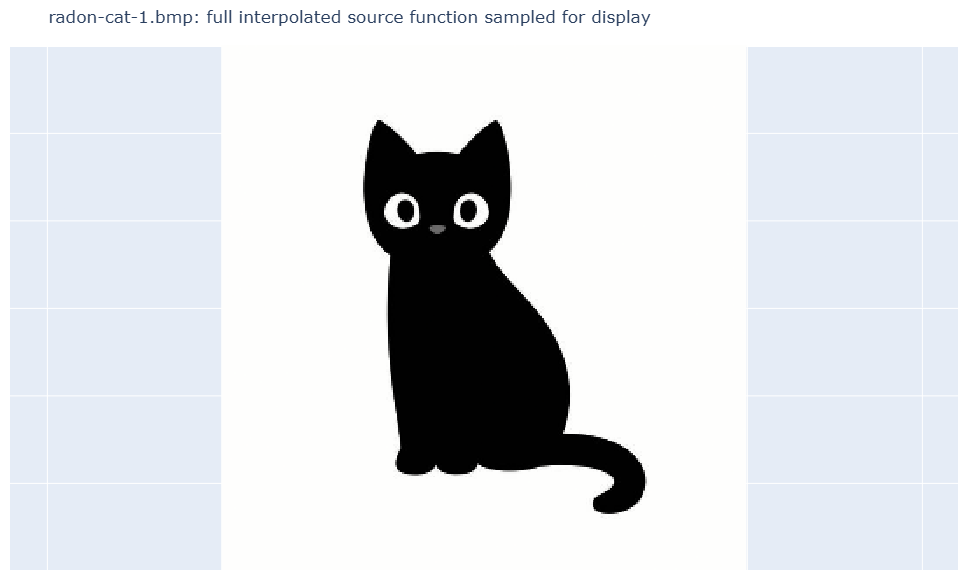

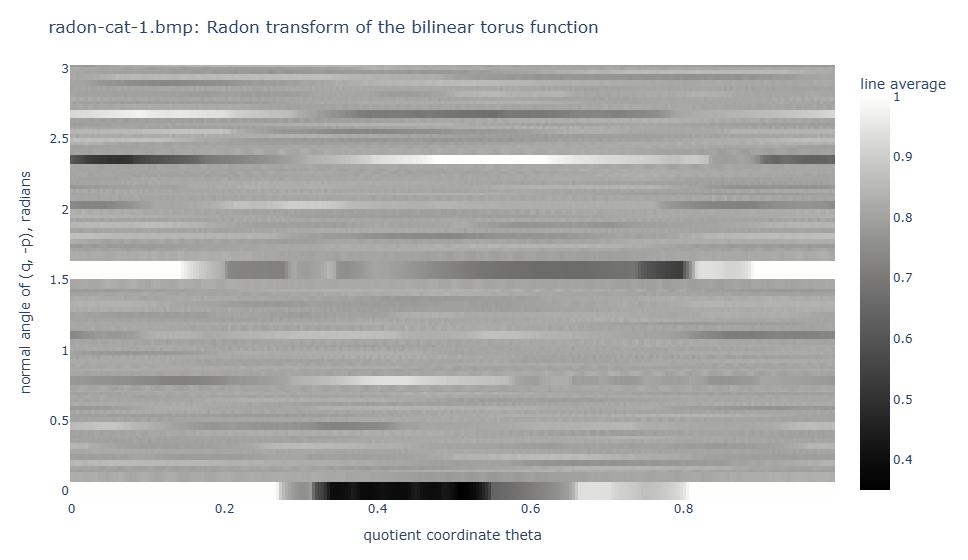

## `radon-cat-2.bmp`

Loaded `radon-cat-2.bmp` as `1000 x 1000` samples. The direct Fourier transform below is computed on that full sample grid; the cutoff only truncates which modes are inverted.

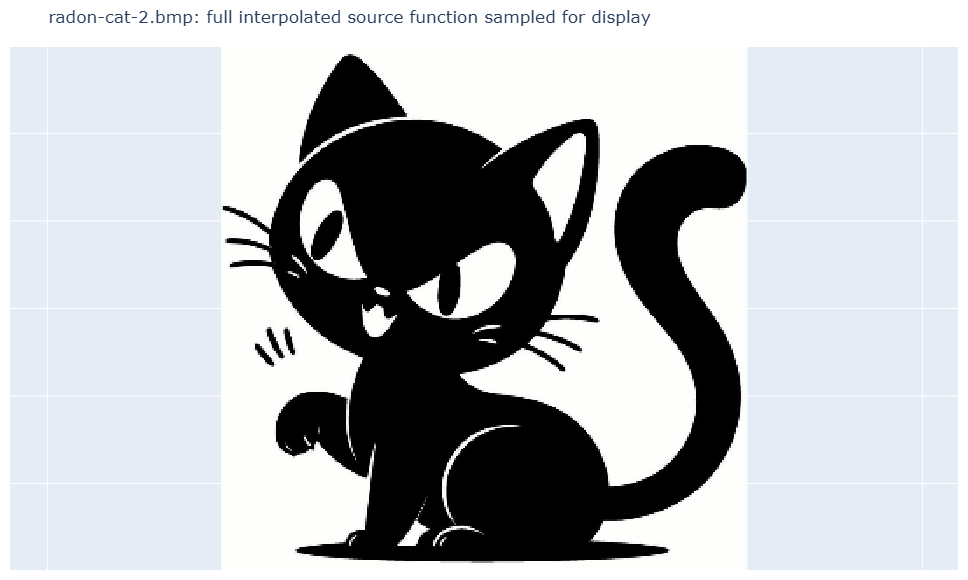

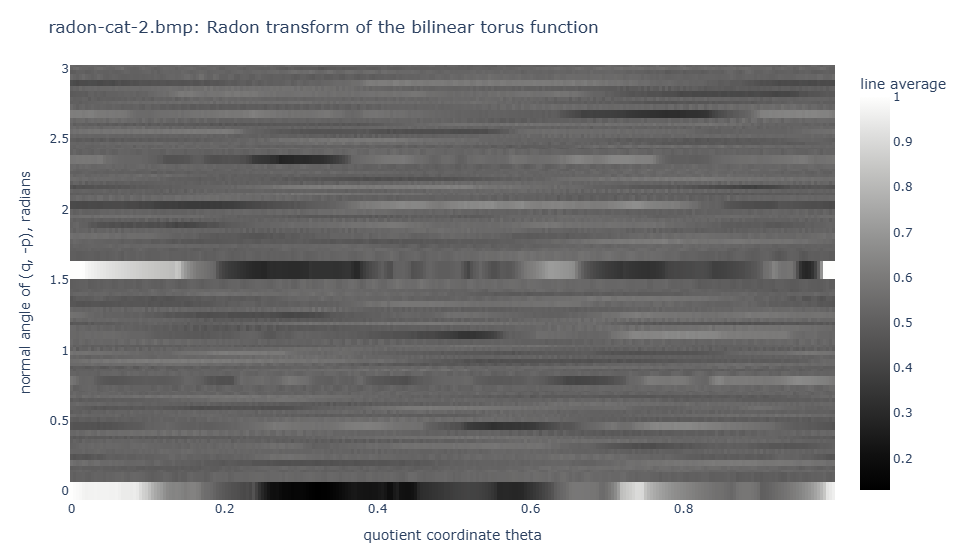

In [ ]:
def prepare_cat_image(path):
    """Load one BMP image and display its cutoff-independent Radon context."""

    md(f"## `{path}`")

    # The loaded image samples are the model data. No smaller image replaces
    # them; all direct Fourier coefficients use this full 1000 x 1000 grid.
    rgb = load_bmp_rgb(path)
    samples = np.clip(rgb_to_gray(rgb), 0, 1)
    if samples.shape != (1000, 1000):
        raise ValueError(f"Expected a 1000 x 1000 image, got {samples.shape}.")

    source_plot = sample_interpolated_function(samples, PLOT_GRID_SIZE)
    full_fourier_coeffs = full_grid_fourier_coefficients(samples)

    md(
        f"Loaded `{path}` as `{samples.shape[0]} x {samples.shape[1]}` samples. "
        "The direct Fourier transform below is computed on that full sample grid; "
        "the cutoff only truncates which modes are inverted."
    )
    show_gray_image(source_plot, f"{path}: full interpolated source function sampled for display", width=560, height=580)

    # Plot representative Radon data before using sparse Radon samples for
    # coefficient recovery.
    sinogram, angles, normals = radon_sinogram(samples)
    theta = np.linspace(0, 1, SINOGRAM_THETA_COUNT, endpoint=False)
    fig = go.Figure(
        go.Heatmap(
            z=sinogram,
            x=theta,
            y=angles,
            colorscale="gray",
            colorbar=dict(title="line average"),
        )
    )
    fig.update_xaxes(title="quotient coordinate theta")
    fig.update_yaxes(title="normal angle of (q, -p), radians")
    fig.update_layout(
        title=f"{path}: Radon transform of the bilinear torus function",
        width=820,
        height=560,
        margin=dict(l=70, r=20, t=65, b=60),
    )
    fig.show()

    return {
        "path": path,
        "samples": samples,
        "source_plot": source_plot,
        "full_fourier_coeffs": full_fourier_coeffs,
        "radon_coeff_cache": {},
    }


def render_frequency_cutoff(cat_data, k):
    """Render the direct and sparse-Radon Fourier comparison for one cutoff."""

    path = cat_data["path"]
    samples = cat_data["samples"]
    source_plot = cat_data["source_plot"]

    md(f"### Direct Fourier data for `|n| < {k}` and `|m| < {k}`")
    frequencies, direct_coeffs = truncate_full_grid_coefficients(cat_data["full_fourier_coeffs"], k)
    direct_reconstruction = reconstruct_from_coefficients(frequencies, direct_coeffs)
    direct_error = direct_reconstruction - source_plot

    md(
        "These coefficients are selected from the FFT of the full `1000 x 1000` image grid. "
        f"Only the inverse series is truncated to `{len(frequencies) ** 2}` coefficients."
    )
    show_three_images(
        source_plot,
        np.clip(direct_reconstruction, 0, 1),
        np.abs(direct_error),
        f"{path}: direct Fourier reconstruction",
        ("interpolated source", "truncated full-grid FFT", "absolute error"),
        zmin=0,
        zmax=1,
    )

    md(f"### Fourier data through sampled Radon data for `|n| < {k}` and `|m| < {k}`")
    if k not in cat_data["radon_coeff_cache"]:
        cat_data["radon_coeff_cache"][k] = radon_fourier_coefficients(samples, k)
    radon_frequencies, radon_coeffs, radon_data = cat_data["radon_coeff_cache"][k]
    if not np.array_equal(frequencies, radon_frequencies):
        raise ValueError("Direct and Radon frequency lists do not match.")
    radon_reconstruction = reconstruct_from_coefficients(frequencies, radon_coeffs)
    radon_vs_direct_image_error = radon_reconstruction - direct_reconstruction

    md(
        f"The Radon route stores `{radon_data['total_values']}` values: "
        f"`{len(radon_data['normals'])}` sampled primitive integer frequency directions times "
        f"`{radon_data['theta_count']}` quotient samples. "
        f"The target budget is about `{RADON_DATA_BUDGET_FACTOR * k**2}` values. "
        f"Each stored line average uses `{radon_data['line_quadrature_count']}` points along the line. "
        "Fourier coefficients are then read from the DFT of each sampled projection after angular interpolation when needed."
    )
    show_three_images(
        np.clip(direct_reconstruction, 0, 1),
        np.clip(radon_reconstruction, 0, 1),
        np.abs(radon_vs_direct_image_error),
        f"{path}: direct versus Radon-derived reconstruction",
        ("truncated full-grid FFT", "sampled Radon interpolation", "absolute difference"),
        zmin=0,
        zmax=1,
    )

    md("### Compare the Fourier data")
    coefficient_error = direct_coeffs - radon_coeffs
    md(
        f"Maximum coefficient error: `{np.max(np.abs(coefficient_error)):.3e}`. "
        f"RMS coefficient error: `{np.sqrt(np.mean(np.abs(coefficient_error) ** 2)):.3e}`."
    )
    show_fourier_comparison(frequencies, direct_coeffs, radon_coeffs, f"{path}: Fourier coefficients")


CAT_DATA = [prepare_cat_image(image_file) for image_file in IMAGE_FILES]

cutoff_slider = widgets.IntSlider(
    value=DEFAULT_K,
    min=MIN_K,
    max=MAX_K,
    step=1,
    description="cutoff K",
    continuous_update=False,
)
cutoff_text = widgets.BoundedIntText(
    value=DEFAULT_K,
    min=MIN_K,
    max=MAX_K,
    step=1,
    description="K",
    continuous_update=False,
)
cutoff_link = widgets.link((cutoff_slider, "value"), (cutoff_text, "value"))
cutoff_output = widgets.Output()


def update_cutoff_figures(change=None):
    """Recompute cutoff-dependent figures after the user commits a new K."""

    k = int(cutoff_slider.value)
    with cutoff_output:
        clear_output(wait=True)
        md(
            f"## Fourier cutoff `K = {k}`\n\n"
            "The direct path computes the full-grid FFT once and truncates modes only at inversion. "
            "The Radon path stores a sparse Radon table with about `2*K^(2/3)` sampled primitive directions and about `2*K^(4/3)` theta samples, "
            "then uses angular interpolation between sampled projections and a DFT in theta to estimate the Fourier coefficients."
        )
        for cat_data in CAT_DATA:
            render_frequency_cutoff(cat_data, k)


cutoff_slider.observe(update_cutoff_figures, names="value")
update_cutoff_figures()

display(widgets.VBox([widgets.HBox([cutoff_slider, cutoff_text]), cutoff_output]))


## What to take away

The direct reconstruction now starts from the Fourier transform of the full `1000 x 1000` sample grid. Changing the cutoff does not recompute a smaller direct Fourier transform; it only chooses which modes to keep when evaluating the inverse Fourier series.

The Radon route stores a sparse table of Radon data. For a cutoff $K$, it samples primitive integer frequency directions and quotient coordinates so the stored table has roughly $4K^2$ values, with more resolution assigned to theta than to angle. The line averages themselves are evaluated at full image-grid resolution; the loss comes from storing only sparse Radon samples and then using a DFT in the quotient coordinate to recover Fourier coefficients.
